In [1]:
# MAPS IN LAYERS — Mining sites and mining conflicts in Latin America
#
# Goal: put the two datasets on the same map, in three layers that can be switched on one after the other:
# 1. the countries, coloured by region (South America / Mexico & Central America / Caribbean);
# 2. the large-scale mining sites (ICMM);
# 3. the conflict zones: the provinces / states where mining conflicts were recorded (OCMAL list).
# The notebook makes four propositions of the same idea, so the team can pick one for the report and the presentation.
#
# Project question: Do resource-rich countries in Latin America see more killings of environmental defenders?
# This notebook shows the first link of the chain: do mining activity and mining conflicts happen in the same places?
#
# File — What it contains
# icmm_sites_latam.csv — one row per large-scale mining site (709): name, country, coordinates, minerals (from icmm_mining_sites_cleaning.ipynb)
# all_latin_america_conflicts_WITH_REGION.csv — one row per mining conflict and country (289): title, country, place written as text, start year
# latam_countries.geojson, latam_admin1.geojson — country and province borders (Natural Earth, public domain), simplified for Latin America
#
# The four propositions
# A. Interactive map (plotly) with three buttons: 1 countries → 2 + mining sites → 3 + conflict zones, and buttons to zoom on the Andes or Mexico & Central America
# B. Interactive map on a real background map (folium / Leaflet), with a layer menu to switch each layer on and off
# C. Country view: countries shaded by number of conflicts, with a bubble for the number of mining sites; plus a country chart
# D. Static maps for the report: the three layers side by side, and the same layers saved as aligned transparent PNGs for slides
#
# Know before using it:
# - The conflict list has no coordinates. Each conflict is placed in its province from the place written in the list (step 3B), so a conflict zone = a whole province, not a point.
# - ICMM covers large-scale mining (mines, smelters, refineries). Small-scale and illegal mining is mostly missing.
# - OCMAL is a monitoring list (conflicts started 1972–2019): more monitoring means more conflicts listed.
# - A province is drawn with a circle sized by its number of conflicts, so large provinces do not look worse only because they are large.
#
# Every map is saved in the figures/ folder (HTML for the interactive ones, PNG for the static ones).

In [2]:
# 1) Setup
#
# What:
# - libraries: pandas and numpy (tables), json (map borders), matplotlib (static maps, and Path.contains_points to find in which province a site is), Path (files);
# - where the data comes from: a file next to this notebook (or in a sub-folder) is used first; otherwise it is read from our GitHub repo;
#   the borders, if they are not next to the notebook or in the repo, are downloaded from Natural Earth and simplified here (slower, about 40 MB, once);
# - REGION: the countries of the region with their ISO3 code and region (the same list as the other notebooks);
# - the colours of the layers, used by every proposition.
#
# Output: nothing is printed.

In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.collections import PolyCollection
from matplotlib.path import Path as MplPath

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

REPO = "https://raw.githubusercontent.com/len-chou/TeamTokio---Week-3-Project-/refs/heads/main/"
NATURAL_EARTH = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# iso3 -> (country, region); same list as the ICMM and conflict notebooks (+ French Guiana, Jamaica, Trinidad and Tobago)
REGION = {
    "ARG": ("Argentina", "South America"), "BOL": ("Bolivia", "South America"), "BRA": ("Brazil", "South America"),
    "CHL": ("Chile", "South America"), "COL": ("Colombia", "South America"), "ECU": ("Ecuador", "South America"),
    "PRY": ("Paraguay", "South America"), "PER": ("Peru", "South America"), "URY": ("Uruguay", "South America"),
    "VEN": ("Venezuela", "South America"), "GUY": ("Guyana", "South America"), "SUR": ("Suriname", "South America"),
    "GUF": ("French Guiana", "South America"),
    "MEX": ("Mexico", "Mexico & Central America"), "GTM": ("Guatemala", "Mexico & Central America"),
    "HND": ("Honduras", "Mexico & Central America"), "SLV": ("El Salvador", "Mexico & Central America"),
    "NIC": ("Nicaragua", "Mexico & Central America"), "CRI": ("Costa Rica", "Mexico & Central America"),
    "PAN": ("Panama", "Mexico & Central America"), "BLZ": ("Belize", "Mexico & Central America"),
    "CUB": ("Cuba", "Caribbean"), "DOM": ("Dominican Republic", "Caribbean"), "HTI": ("Haiti", "Caribbean"),
    "JAM": ("Jamaica", "Caribbean"), "TTO": ("Trinidad and Tobago", "Caribbean"),
}
ISO_OF = {country: iso for iso, (country, _) in REGION.items()}

# colours of the layers (light mode; the same as the slides)
OCEAN, OTHER_LAND = "#e6edf3", "#dcdad4"
REGION_FILL = {"South America": "#f3ead6", "Mexico & Central America": "#eae0ef", "Caribbean": "#d7ece5"}
SITE_COLOURS = {"critical mineral": "#1f6fd1", "gold": "#e0a000", "other minerals": "#7d8696"}
ZONE = "#e0402f"


def show_fig(fig, html_name):
    """Save a plotly map as an HTML page, then show it here; if this notebook cannot show plotly, say where the page is."""
    path = FIG_DIR / html_name
    fig.write_html(str(path), include_plotlyjs="cdn")
    try:
        fig.show()
    except Exception as err:
        print(f"The map could not be shown inside the notebook ({type(err).__name__}).")
        print(f"Open {path} in a browser instead. To show maps here: pip install --upgrade nbformat ipywidgets, then restart the kernel.")

In [4]:
# 2) Load the data
#
# What: find_file() looks for a file in this notebook's folder and its sub-folders; read_csv_any() and read_geojson_any() use that file if it exists, else the copy in our GitHub repo.
# For the borders there is a third way: build them from the original Natural Earth files (make_borders_from_natural_earth), keeping only Latin America and simplifying the lines
# (Douglas–Peucker: points closer than about 2 km to the line are removed), so the maps stay light.
#
# Why: the notebook then runs on any computer, with or without the files downloaded.
#
# Output: where each file was read from, and the size of each table.

In [5]:
def find_file(name):
    found = sorted(Path(".").rglob(name))
    return found[0] if found else None

def read_csv_any(name):
    local = find_file(name)
    source = local if local else REPO + name
    print(f"{name}: read from {source}")
    return pd.read_csv(source)

def simplify_ring(points, tol):
    """Douglas-Peucker: keep only the points that change the shape by more than tol degrees."""
    if len(points) < 5:
        return points
    keep = np.zeros(len(points), bool)
    keep[0] = keep[-1] = True
    stack = [(0, len(points) - 1)]
    while stack:
        a, b = stack.pop()
        if b <= a + 1:
            continue
        seg, d = points[b] - points[a], points[a + 1:b] - points[a]
        norm = np.hypot(*seg)
        dist = np.abs(seg[0] * d[:, 1] - seg[1] * d[:, 0]) / norm if norm else np.hypot(d[:, 0], d[:, 1])
        i = int(np.argmax(dist))
        if dist[i] > tol:
            keep[a + 1 + i] = True
            stack += [(a, a + 1 + i), (a + 1 + i, b)]
    return points[keep]

def polygons(geom):
    return [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]

def simplify_geometry(geom, tol):
    out = []
    for poly in polygons(geom):
        rings = [np.round(simplify_ring(np.array(r, float), tol), 3).tolist() for r in poly]
        rings = [r for r in rings if len(r) >= 4]
        if not rings:   # tiny island: keep it unsimplified rather than lose it
            rings = [np.round(np.array(r, float), 3).tolist() for r in poly]
        if rings:
            out.append(rings)
    return {"type": "MultiPolygon", "coordinates": out}

def make_borders_from_natural_earth():
    """Download the Natural Earth borders and keep Latin America (only used if the simplified files are not found)."""
    import urllib.request
    print("Downloading Natural Earth borders (about 45 MB, once)...")
    countries_ne = json.load(urllib.request.urlopen(NATURAL_EARTH + "ne_50m_admin_0_countries.geojson"))
    provinces_ne = json.load(urllib.request.urlopen(NATURAL_EARTH + "ne_10m_admin_1_states_provinces.geojson"))
    countries_out = []
    for f in countries_ne["features"]:
        p, geom = f["properties"], f["geometry"]
        iso = p["ADM0_A3"]
        if iso == "FRA":          # France: keep only French Guiana
            geom = {"type": "MultiPolygon", "coordinates": [pl for pl in polygons(geom)
                    if -55 < np.mean(np.array(pl[0])[:, 0]) < -51 and 1 < np.mean(np.array(pl[0])[:, 1]) < 7]}
            iso = "GUF"
        # keep only the pieces of the country that lie in the region (drops e.g. Alaska, Hawaii, Pacific islands)
        geom = {"type": "MultiPolygon", "coordinates": [pl for pl in polygons(geom)
                if -125 < np.mean(np.array(pl[0])[:, 0]) < -25 and -60 < np.mean(np.array(pl[0])[:, 1]) < 40]}
        if not geom["coordinates"]:
            continue
        name, sub = REGION.get(iso, (p["NAME"], "Other"))
        lx, ly = (-53.2, 4.0) if iso == "GUF" else (p["LABEL_X"], p["LABEL_Y"])
        countries_out.append({"type": "Feature", "properties": {"name": name, "iso3": iso, "subregion": sub, "in_project": iso in REGION,
                              "label_lon": lx, "label_lat": ly}, "geometry": simplify_geometry(geom, 0.03)})
    provinces_out = []
    for f in provinces_ne["features"]:
        p = f["properties"]
        iso = "GUF" if p["name"] == "Guyane française" else p["adm0_a3"]
        if iso not in REGION or p["name"] is None:
            continue
        provinces_out.append({"type": "Feature", "id": f"{iso}|{p['name']}",
                              "properties": {"admin1_id": f"{iso}|{p['name']}", "admin1": p["name"], "iso3": iso,
                                             "country": REGION[iso][0], "label_lon": p["longitude"], "label_lat": p["latitude"]},
                              "geometry": simplify_geometry(f["geometry"], 0.02)})
    return ({"type": "FeatureCollection", "features": countries_out},
            {"type": "FeatureCollection", "features": provinces_out})

def read_borders():
    try:
        out = []
        for name in ["latam_countries.geojson", "latam_admin1.geojson"]:
            local = find_file(name)
            if local:
                out.append(json.load(open(local, encoding="utf-8")))
            else:
                out.append(pd.read_json(REPO + name, typ="series").to_dict())
            print(f"{name}: read from {local or REPO + name}")
        return tuple(out)
    except Exception as err:
        print(f"Simplified borders not found ({type(err).__name__}).")
        return make_borders_from_natural_earth()

sites = read_csv_any("icmm_sites_latam.csv")
raw_conflicts = read_csv_any("all_latin_america_conflicts_WITH_REGION.csv")
countries_gj, provinces_gj = read_borders()
# keep only the provinces of our country list (the borders file can also hold e.g. Puerto Rico)
provinces_gj = {"type": "FeatureCollection", "features": [f for f in provinces_gj["features"] if f["properties"]["iso3"] in REGION]}
print("sites:", sites.shape, "| conflict rows:", raw_conflicts.shape,
      "| countries:", len(countries_gj["features"]), "| provinces:", len(provinces_gj["features"]))

icmm_sites_latam.csv: read from dataset/ICMM/icmm_sites_latam.csv
all_latin_america_conflicts_WITH_REGION.csv: read from dataset/all_latin_america_conflicts_WITH_REGION.csv
Simplified borders not found (FileNotFoundError).
sites: (709, 33) | conflict rows: (289, 5) | countries: 53 | provinces: 458


In [6]:
# 3) Put each conflict in its province
#
# 3A. The conflicts, each counted once
#
# What: the same cleaning as mining_conflicts_cleaning.ipynb, in short: English country names, ISO3, an ID per conflict (MC-001 …), and each conflict once.
# A conflict on a border between two countries (5 of them) is listed under both countries; here it is kept once, under the first country written in its place ("Chile, Argentina (…)" → Chile).
#
# Output: the number of conflicts and of countries.

In [7]:
NAMES = {"México": "Mexico", "Perú": "Peru", "Brasil": "Brazil", "Panamá": "Panama",
         "República Dominicana": "Dominican Republic", "Guayana Francesa": "French Guiana", "Trinidad y Tobago": "Trinidad and Tobago"}
c = pd.DataFrame({
    "conflict_name": raw_conflicts["nombre"].str.strip().str.replace(r"\s{2,}", " ", regex=True),
    "country": raw_conflicts["pais"].str.strip().replace(NAMES),
    "place_raw": raw_conflicts["lugar"],
    "start_year": raw_conflicts["inicio_conflicto"].astype("Int64"),
})
c["first_in_place"] = c["place_raw"].str.split("(").str[0].str.split(",").str[0].str.strip().replace(NAMES)
ids = {name: f"MC-{i:03d}" for i, name in enumerate(c["conflict_name"].drop_duplicates(), start=1)}
c["conflict_id"] = c["conflict_name"].map(ids)
border = c.duplicated("conflict_id", keep=False)
conflicts = c[~border | (c["country"] == c["first_in_place"])].copy()
assert conflicts["conflict_id"].is_unique and len(conflicts) == c["conflict_id"].nunique()
conflicts["iso3"] = conflicts["country"].map(ISO_OF)
conflicts["subregion"] = conflicts["iso3"].map(lambda i: REGION[i][1])
print(f"{len(conflicts)} conflicts in {conflicts['country'].nunique()} countries")

284 conflicts in 20 countries


In [8]:
# 3B. Match the place text to a province
#
# What: RULES gives, for each country, the provinces (with their Natural Earth names) and the words that point to them in the place text:
# the name of the province, and the towns, mines or valleys that the list uses instead (e.g. "Andalgalá" → Catamarca, "Huanuni" → Oruro).
# find_admin1() looks at the place text first, then at the title; the first rule that matches wins, so more specific rules come first
# (e.g. "Valle del Cauca" before "Cauca", "Baja California Sur" before "Baja California").
#
# Why: the list has no coordinates. The province is the most precise level that can be read from almost every place text.
#
# ⚠ The rules were checked by hand, conflict by conflict. One conflict cannot be placed: "Mina contamina El Valle" (Dominican Republic) has an empty place.
# The place text was cut at 60 characters in the source; for some Brazilian conflicts only the state is left, which is enough here.
#
# Check: every province named in RULES exists in the borders file.
#
# Output: how many conflicts were placed, on the place or on the title, and the ones that could not be placed.

In [9]:
RULES = {
    "ARG": [
        ("Jujuy", ["jujuy", "humahuaca", "susques", "rinconada", "jujeña"]),
        ("Catamarca", ["catamarca", "tinogasta", "andalgalá", "fiambala", "antofagasta de la sierra", "belén"]),
        ("Salta", ["salta", "metan"]),
        ("La Rioja", ["la rioja", "famatina", "chilecito"]),
        ("San Juan", ["san juan", "pachón", "veladero", "pascua lama"]),
        ("Mendoza", ["mendoza", "malargüe", "uspallata", "valle de uco", "san rafael"]),
        ("Neuquén", ["neuquén", "loncopue"]),
        ("Río Negro", ["río negro"]),
        ("Chubut", ["chubut", "esquel"]),
        ("Santa Cruz", ["santa cruz"]),
        ("Buenos Aires", ["sierra de la ventana", "buenos aires"]),
    ],
    "BOL": [
        ("La Paz", ["coro coro"]),
        ("Oruro", ["oruro", "huanuni", "challapata", "poopó"]),
        ("Potosí", ["potosí", "nor chichas", "vitichi"]),
    ],
    "BRA": [
        ("Pará", ["pará", "oriximina", "juruti", "curuçá", "senador josé porfirio", "carajás"]),
        ("Maranhão", ["maranhão", "açailândia"]),
        ("Amapá", ["amapá", "serra do navio"]),
        ("Rondônia", ["rondônia", "porto velho", "cinta larga"]),
        ("Piauí", ["piauí"]),
        ("Bahia", ["bahia", "bahía", "caetité", "ilhéus", "santo amaro"]),
        ("Minas Gerais", ["minas gerais", "(mg)", "paracatu", "vazante", "gandarela"]),
        ("Rio de Janeiro", ["rio de janeiro", "río de janeiro"]),
        ("Santa Catarina", ["santa catarina", "anitápolis"]),
    ],
    "CHL": [
        ("Tarapacá", ["tarapacá", "huara", "pica", "huatacondo", "cancosa"]),
        ("Arica y Parinacota", ["arica", "parinacota", "putre", "general lagos", "lluta"]),
        ("Atacama", ["atacama-antofagasta", "maricunga", "copiapó", "chañaral", "huasco", "paipote", "caserones", "cerro casale", "pascua lama", "tierra amarilla"]),
        ("Antofagasta", ["antofagasta", "san pedro de atacama", "peine", "toconao", "quillagua"]),
        ("Coquimbo", ["coquimbo", "andacollo", "choapa", "salamanca", "caimanes", "ovalle", "vicuña", "elqui", "monte patria", "illapel", "la higuera", "limarí"]),
        ("Valparaíso", ["valparaíso", "aconcagua", "llay llay", "las ventanas", "putaendo"]),
        ("Región Metropolitana de Santiago", ["región metropolitana", "maipú"]),
        ("Maule", ["constitución", "maule", "putú"]),
        ("Bío-Bío", ["bío bío", "bio bio", "biobío", "penco", "arauco"]),
        ("La Araucanía", ["araucanía", "carahue"]),
        ("Los Lagos", ["chiloé", "guafo"]),
        ("Aisén del General Carlos Ibáñez del Campo", ["aysen", "aysén", "chile chico"]),
        ("Magallanes y Antártica Chilena", ["magallanes", "riesco"]),
    ],
    "COL": [
        ("Valle del Cauca", ["valle del cauca", "buenaventura", "zaragoza"]),
        ("Cauca", ["quilichao", "cauca"]),
        ("Chocó", ["carmen del darién", "murindó", "mandé"]),
        ("Antioquia", ["antioquia", "caramanta", "jerico"]),
        ("Córdoba", ["córdoba", "montelibano", "cerro matoso"]),
        ("Quindío", ["quindío"]),
        ("Boyacá", ["boyacá", "tasco", "pisba"]),
        ("Cesar", ["cesar"]),
        ("La Guajira", ["guajira", "cerrejón"]),
        ("Risaralda", ["risaralda", "quinchia"]),
        ("Caldas", ["marmato"]),
        ("Tolima", ["tolima", "cajamarca", "colosa"]),
        ("Santander", ["santander", "almorzadero", "cerrito", "chucurí", "landázuri", "landazuri", "vélez", "santurbán"]),
    ],
    "CRI": [
        ("Limón", ["talamanca", "bri bri"]),
        ("Alajuela", ["crucitas", "río san juan"]),
    ],
    "ECU": [
        ("Bolivar", ["las naves", "bolivar"]),
        ("Loja", ["loja"]),
        ("Morona Santiago", ["morona santiago", "cóndor"]),
        ("Zamora Chinchipe", ["zamora"]),
        ("Imbabura", ["imbabura", "intag"]),
        ("Azuay", ["azuay", "shaglly", "quimsacocha"]),
    ],
    "SLV": [
        ("Cabañas", ["cabañas", "sensuntepeque"]),
    ],
    "GTM": [
        ("Jutiapa", ["asunción mita", "cerro blanco"]),
        ("Huehuetenango", ["huehuetenango", "chiantla"]),
        ("Totonicapán", ["totonicapán", "momostenango"]),
        ("Quezaltenango", ["quetzaltenango", "cabricán"]),
        ("San Marcos", ["san marcos", "tajumulco", "ixtahuacan"]),
        ("Santa Rosa", ["santa rosa", "escobal"]),
        ("Izabal", ["izabal", "el estor"]),
        ("Guatemala", ["san jose del golfo", "san pedro ayampuc", "san juan sacatepéquez", "la puya"]),
    ],
    "GUF": [
        ("Guyane française", ["cayenne", "kow"]),
    ],
    "HND": [
        ("Atlántida", ["atlántida", "tela"]),
        ("Colón", ["colon", "guapinol"]),
        ("Choluteca", ["choluteca", "el triunfo"]),
        ("Francisco Morazán", ["francisco de morazán", "valle de siria"]),
        ("Copán", ["copan", "copán"]),
        ("Santa Bárbara", ["santa bárbara", "santa barbara"]),
    ],
    "MEX": [
        ("Baja California Sur", ["baja california sur", "municipio la paz", "bahía de ulloa"]),
        ("Baja California", ["mexicali", "ensenada", "baja california"]),
        ("San Luis Potosí", ["san luis, potosí", "san luís potosí", "catorce", "wirikuta"]),
        ("Colima", ["colima"]),
        ("Jalisco", ["jalisco"]),
        ("Hidalgo", ["estado de hidalgo", "molango"]),
        ("Guanajuato", ["guanajuato"]),
        ("Michoacán", ["aquila", "michoacán"]),
        ("Oaxaca", ["oaxaca"]),
        ("Chiapas", ["chiapas"]),
        ("Zacatecas", ["zacateca"]),
        ("Coahuila", ["coahuila"]),
        ("Durango", ["durango"]),
        ("Guerrero", ["guerrero"]),
        ("Puebla", ["puebla", "ixtacamaxtitlan"]),
        ("México", ["temascaltepec", "estado de méxico"]),
        ("Morelos", ["morelos"]),
        ("Querétaro", ["tolimán", "queretaro", "querétaro"]),
        ("Veracruz", ["veracruz"]),
        ("Sonora", ["sonora", "cananea"]),
        ("Chihuahua", ["chihuahua"]),
    ],
    "NIC": [
        ("León", ["león", "larreynaga", "santa cruz de la india"]),
        ("Matagalpa", ["matagalpa"]),
        ("Chontales", ["chontales", "conchales"]),
        ("Nueva Segovia", ["nueva segovia"]),
    ],
    "PAN": [
        ("Colón", ["colón"]),
        ("Los Santos", ["los santos"]),
        ("Coclé", ["coclé", "petaquilla"]),
        ("Chiriquí", ["chiriquí", "chorcha"]),
        ("Veraguas", ["veraguas", "soná"]),
    ],
    "PRY": [
        ("Alto Paraná", ["sureste de paraguay"]),
    ],
    "PER": [
        ("Arequipa", ["arequipa", "caylloma", "islay"]),
        ("Piura", ["piura"]),
        ("Tacna", ["tacna", "candarave"]),
        ("Puno", ["puno"]),
        ("La Libertad", ["quiruvilca", "la libertad"]),
        ("Cajamarca", ["cajamarca", "hualgayoc", "bambamarca", "pulán", "cachachi"]),
        ("Huancavelica", ["huaytara", "huaytará"]),
        ("Ica", ["chincha", ", ica"]),
        ("Áncash", ["ancash", "áncash", "ancach", "huari", "huaraz", "recuay"]),
        ("Cusco", ["cusco", "cuzco", "espinar", "chumbivilcas"]),
        ("Amazonas", ["condorcanqui", "cenepa"]),
        ("Callao", ["callao"]),
        ("Lambayeque", ["reque", "chiclayo", "ferreñafe", "lambayeq"]),
        ("Junín", ["oroya", "morococha", "junin", "junín"]),
        ("Pasco", ["cerro de pasco"]),
        ("Apurímac", ["apurimac", "apurímac", "aymaraes"]),
        ("Moquegua", ["moquehua", "moquegua", "mariscal nieto"]),
        ("Ayacucho", ["ayacucho"]),
        ("Lima", ["lima", "huanchor"]),
    ],
    "DOM": [
        ("La Vega", ["la vega", "loma miranda"]),
        ("Sánchez Ramírez", ["cotuí", "sánchez ramírez"]),
    ],
    "TTO": [
        ("Siparia", ["otaheite"]),
    ],
    "URY": [
        ("Durazno", ["durazno"]),
    ],
    "VEN": [
        ("Zulia", ["zulia", "perijá"]),
        ("Bolívar", ["bolívar", "sifontes"]),
    ],
}


def find_admin1(iso3, place, title):
    """Return (province, 'place' or 'title') for one conflict, or (None, None)."""
    for text, where in ((place, "place"), (title, "title")):
        text = str(text).lower()
        for admin1, words in RULES.get(iso3, []):
            if any(w in text for w in words):
                return admin1, where
    return None, None

known = {f["properties"]["admin1_id"] for f in provinces_gj["features"]}
wrong = [f"{iso}|{a}" for iso, lst in RULES.items() for a, _ in lst if f"{iso}|{a}" not in known]
assert not wrong, f"provinces not in the borders file: {wrong}"

match = conflicts.apply(lambda r: find_admin1(r["iso3"], r["place_raw"], r["conflict_name"]), axis=1)
conflicts["admin1"] = [a for a, _ in match]
conflicts["matched_on"] = [w for _, w in match]
conflicts["admin1_id"] = np.where(conflicts["admin1"].notna(), conflicts["iso3"] + "|" + conflicts["admin1"].fillna(""), None)
print(f"Placed: {conflicts['admin1'].notna().sum()} of {len(conflicts)}", conflicts["matched_on"].value_counts().to_dict())
conflicts.loc[conflicts["admin1"].isna(), ["conflict_id", "country", "conflict_name", "place_raw"]]

Placed: 283 of 284 {'place': 280, 'title': 3}


,conflict_id,country,conflict_name,place_raw
282,MC-278,Dominican Republic,Mina contamina EL Valle,República Dominicana ()


In [10]:
# 3C. Put each mining site in its province, and count per province
#
# What:
# 1. each ICMM site is placed in the province whose border contains its coordinates (matplotlib Path.contains_points);
#    a few sites on the coast fall just outside the simplified border: they get the nearest province of the same country;
# 2. province table: for each province, the number of conflicts, of mining sites, of sites with a critical mineral and with gold,
#    the three most common main minerals, the first and last start year of its conflicts, and the list of its conflicts.
#
# Why: this is the table behind the conflict-zone layer, and the place where the two datasets meet.
#
# Output: the 15 provinces with the most conflicts.

In [11]:
sites["group"] = sites["mineral_group"].replace({"iron, steel & coal": "other minerals", "other": "other minerals"})
prov = pd.DataFrame([f["properties"] for f in provinces_gj["features"]])[["admin1_id", "admin1", "iso3", "country", "label_lon", "label_lat"]]
geoms = {f["properties"]["admin1_id"]: f["geometry"] for f in provinces_gj["features"]}

pts = sites[["lon", "lat"]].to_numpy()
sites["admin1_id"] = None
for iso, group in prov.groupby("iso3"):
    in_country = (sites["iso3"] == iso).to_numpy()
    if not in_country.any():
        continue
    for pid in group["admin1_id"]:
        inside = np.zeros(in_country.sum(), bool)
        for poly in polygons(geoms[pid]):
            inside |= MplPath(np.array(poly[0])).contains_points(pts[in_country])
        sites.loc[sites.index[np.where(in_country)[0][inside]], "admin1_id"] = pid
outside = sites.index[sites["admin1_id"].isna()]
for i in outside:   # coast: nearest province label point of the same country
    cand = prov[prov["iso3"] == sites.at[i, "iso3"]]
    d = np.hypot(cand["label_lon"] - sites.at[i, "lon"], cand["label_lat"] - sites.at[i, "lat"])
    sites.at[i, "admin1_id"] = cand.loc[d.idxmin(), "admin1_id"]
print(f"Sites placed by their coordinates: {len(sites) - len(outside)}, by the nearest province (coast): {len(outside)}")

by_conflicts = conflicts.dropna(subset=["admin1_id"]).groupby("admin1_id").agg(
    n_conflicts=("conflict_id", "size"), first_year=("start_year", "min"), last_year=("start_year", "max"),
    conflicts=("conflict_name", lambda s: " | ".join(s)))
by_sites = sites.groupby("admin1_id").agg(
    n_sites=("icmm_id", "size"), n_critical=("has_critical", "sum"), n_gold=("has_gold", "sum"),
    top_minerals=("mineral_primary", lambda s: ", ".join(s.value_counts().index[:3])))
provinces = prov.merge(by_conflicts, on="admin1_id", how="left").merge(by_sites, on="admin1_id", how="left")
for col in ["n_conflicts", "n_sites", "n_critical", "n_gold"]:
    provinces[col] = provinces[col].fillna(0).astype(int)
provinces["subregion"] = provinces["iso3"].map(lambda i: REGION[i][1])
zones = provinces[provinces["n_conflicts"] > 0].sort_values(["n_conflicts", "n_sites"], ascending=False)
zones.head(15)[["admin1", "country", "n_conflicts", "n_sites", "top_minerals", "first_year", "last_year"]]

Sites placed by their coordinates: 703, by the nearest province (coast): 6


,admin1,country,n_conflicts,n_sites,top_minerals,first_year,last_year
150,Coquimbo,Chile,12,9,"copper, gold, iron ore",1997,2016
453,Zacatecas,Mexico,10,14,"silver, gold, zinc",1980,2018
147,Atacama,Chile,7,38,"copper, gold, iron ore",1989,2018
7,Antofagasta,Chile,7,31,"copper, gold, lithium",2000,2017
22,Pará,Brazil,7,30,"gold, bauxite / aluminium, iron ore",1979,2012
133,Cajamarca,Peru,7,10,"gold, copper, silver",1993,2010
437,Minas Gerais,Brazil,6,68,"iron ore, gold, steel",1990,2008
87,Sonora,Mexico,6,22,"gold, copper, iron ore",1999,2016
447,Puebla,Mexico,6,0,NaN,2009,2016
4,Oruro,Bolivia,5,18,"tin, silver, zinc",2001,2010


In [12]:
# 3D. How much do the two layers overlap?
#
# What: two simple comparisons.
# 1. Of the conflicts that could be placed, how many are in a province that also has at least one large mining site?
# 2. Across all provinces of the 23 project countries: the share of provinces with a recorded conflict, for provinces with at least one large site and for provinces with none.
#
# Why: this is the number behind the map. It says whether conflicts are recorded more often where large mines are.
#
# ⚠ It is an association, not a cause: provinces with mines are often larger and better monitored, and some conflicts are about projects that never became mines.
#
# Output: the share of conflicts in provinces with mines, then the comparison table.

In [13]:
placed = zones["n_conflicts"].sum()
with_sites = zones.loc[zones["n_sites"] > 0, "n_conflicts"].sum()
print(f"{with_sites} of {placed} placed conflicts ({with_sites / placed:.0%}) are in provinces that also have at least one large mining site.")

project = provinces[~provinces["iso3"].isin(["GUF", "JAM", "TTO"])].copy()
project["has_site"] = np.where(project["n_sites"] > 0, "at least one large site", "no large site")
overlap = project.groupby("has_site").agg(provinces=("admin1_id", "size"),
                                          with_conflict=("n_conflicts", lambda s: int((s > 0).sum())),
                                          conflicts=("n_conflicts", "sum"))
overlap["share_with_conflict"] = (overlap["with_conflict"] / overlap["provinces"]).round(3)
overlap

221 of 283 placed conflicts (78%) are in provinces that also have at least one large mining site.


,provinces,with_conflict,conflicts,share_with_conflict
has_site,,,,
at least one large site,124,84,220,0.677
no large site,303,43,61,0.142


In [14]:
# 4) Proposition A — Interactive map with three steps (plotly)
#
# What: one map with the three layers, and two rows of buttons above it:
# - "1 Countries", "2 + Mining sites", "3 + Conflict zones": the layers appear one after the other, like the slides;
# - "All of Latin America", "Andes", "Mexico & Central America": zoom on a part of the region.
# You can also click an item of the legend to hide or show it, zoom with the mouse, and move the mouse over a site or a province to see its details
# (for a province: its conflicts, its number of large sites and their main minerals).
#
# How:
# - layer 1: one go.Choropleth per region, drawn from our own borders (latam_countries.geojson), so the map does not need plotly's own world map;
# - layer 2: one go.Scattergeo per mineral group (critical mineral / gold / other);
# - layer 3: the provinces with conflicts, lightly tinted (go.Choropleth), and a circle on each of them whose area is proportional to its number of conflicts (go.Scattergeo);
# - the buttons change which traces are visible ("visible" list) or the zoom (geo.center and geo.projection.scale);
# - projection: Lambert azimuthal equal-area centred on Latin America (areas are not distorted).
#
# Output: the map, also saved as figures/A_map_layers.html (open it in a browser, or send it: it works without Python).

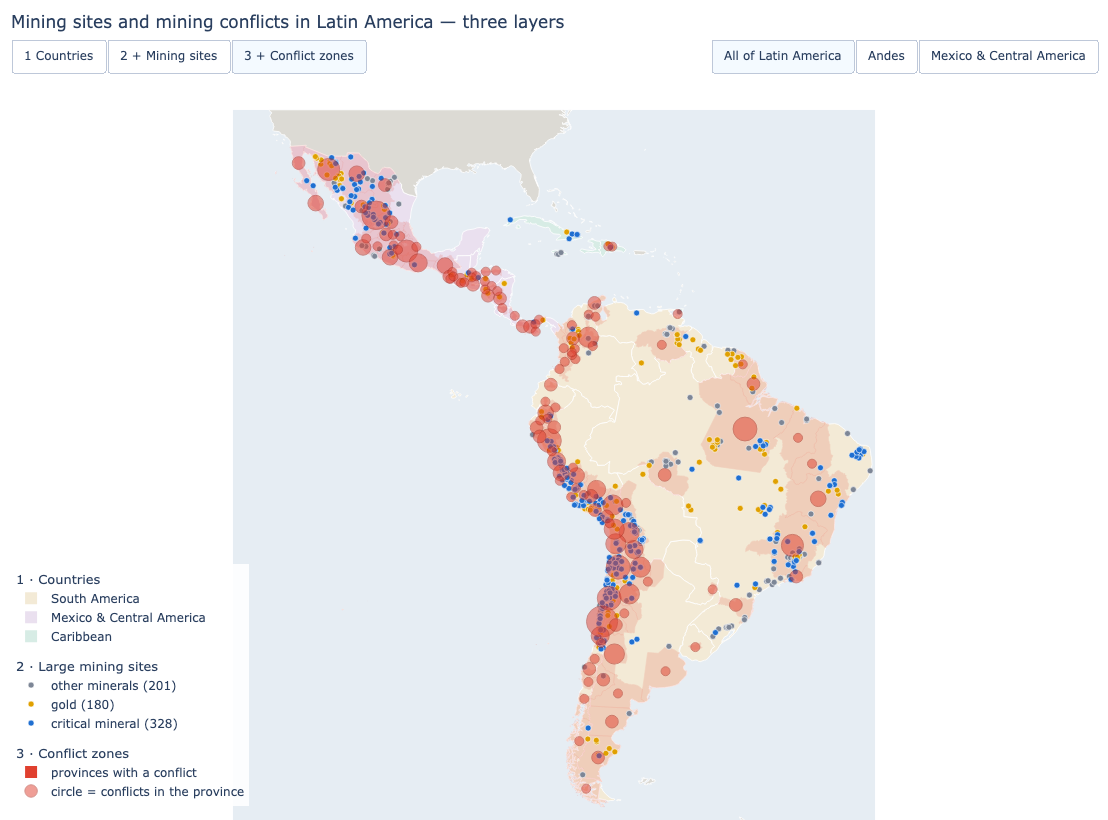

In [15]:
try:
    import plotly.graph_objects as go

    def region_trace(region, colour):
        feats = [f for f in countries_gj["features"] if (f["properties"]["subregion"] if f["properties"]["in_project"] else "Other") == region]
        return go.Choropleth(
            geojson={"type": "FeatureCollection", "features": feats}, featureidkey="properties.iso3",
            locations=[f["properties"]["iso3"] for f in feats], z=[1] * len(feats),
            colorscale=[[0, colour], [1, colour]], showscale=False, marker_line_color="#ffffff", marker_line_width=0.8,
            name=region if region != "Other" else "Other countries", showlegend=region != "Other", legendgroup="1",
            legendgrouptitle_text="1 · Countries" if region == "South America" else None,
            text=[f["properties"]["name"] for f in feats], hovertemplate="%{text}<extra></extra>")

    layer1 = [region_trace(r, col) for r, col in REGION_FILL.items()] + [region_trace("Other", OTHER_LAND)]

    layer2 = []
    for grp in ["other minerals", "gold", "critical mineral"]:
        s = sites[sites["group"] == grp]
        layer2.append(go.Scattergeo(
            lon=s["lon"], lat=s["lat"], mode="markers", name=f"{grp} ({len(s)})", legendgroup="2",
            legendgrouptitle_text="2 · Large mining sites" if grp == "other minerals" else None,
            marker=dict(size=6, color=SITE_COLOURS[grp], line=dict(width=0.6, color="#ffffff")),
            text=s["site_name"] + " (" + s["country"] + ")<br>" + s["minerals_all"].fillna("") + "<br>" + s["asset_main"]
                 + " · confidence " + s["confidence_factor"].astype(str),
            hovertemplate="%{text}<extra></extra>"))

    z = zones.copy()
    z["hover"] = ("<b>" + z["admin1"] + " (" + z["country"] + ")</b><br>" + z["n_conflicts"].astype(str) + " conflicts, "
                  + z["n_sites"].astype(str) + " large sites" + np.where(z["n_sites"] > 0, " (" + z["top_minerals"].fillna("") + ")", "")
                  + "<br>" + z["conflicts"].str.slice(0, 300).str.replace(" | ", "<br>· ", regex=False).radd("· "))
    zone_feats = [f for f in provinces_gj["features"] if f["properties"]["admin1_id"] in set(z["admin1_id"])]
    layer3 = [
        go.Choropleth(geojson={"type": "FeatureCollection", "features": zone_feats}, featureidkey="properties.admin1_id",
                      locations=z["admin1_id"], z=[1] * len(z), colorscale=[[0, ZONE], [1, ZONE]], showscale=False,
                      marker_opacity=0.16, marker_line_color=ZONE, marker_line_width=0.6,
                      name="provinces with a conflict", legendgroup="3", legendgrouptitle_text="3 · Conflict zones",
                      showlegend=True, text=z["hover"], hovertemplate="%{text}<extra></extra>"),
        go.Scattergeo(lon=z["label_lon"], lat=z["label_lat"], mode="markers", name="circle = conflicts in the province",
                      legendgroup="3", marker=dict(size=np.sqrt(z["n_conflicts"]) * 9, color=ZONE, opacity=0.5,
                                                   line=dict(width=1, color="#a8261a")),
                      text=z["hover"], hovertemplate="%{text}<extra></extra>"),
    ]
    traces = layer1 + layer2 + layer3
    n1, n2, n3 = len(layer1), len(layer2), len(layer3)
    steps = {"1 Countries": [True] * n1 + [False] * (n2 + n3),
             "2 + Mining sites": [True] * (n1 + n2) + [False] * n3,
             "3 + Conflict zones": [True] * (n1 + n2 + n3)}
    views = {"All of Latin America": dict(lon=-78, lat=-10, scale=1.0),
             "Andes": dict(lon=-70, lat=-20, scale=2.6),
             "Mexico & Central America": dict(lon=-95, lat=19, scale=2.4)}

    figA = go.Figure(traces)
    figA.update_geos(visible=False, bgcolor=OCEAN, projection_type="azimuthal equal area",
                     projection_rotation=dict(lon=-78, lat=-10), center=dict(lon=-78, lat=-10), projection_scale=1.0,
                     lonaxis_range=[-120, -34], lataxis_range=[-57, 34])
    figA.update_layout(
        height=820, margin=dict(l=0, r=0, t=110, b=0), paper_bgcolor="#ffffff",
        title=dict(text="Mining sites and mining conflicts in Latin America — three layers", x=0.01, y=0.98),
        legend=dict(x=0.01, y=0.02, bgcolor="rgba(255,255,255,0.85)", groupclick="toggleitem"),
        updatemenus=[
            dict(type="buttons", direction="right", x=0.01, y=1.10, xanchor="left", showactive=True, active=2,
                 buttons=[dict(label=label, method="restyle", args=[{"visible": vis}]) for label, vis in steps.items()]),
            dict(type="buttons", direction="right", x=0.99, y=1.10, xanchor="right", showactive=True, active=0,
                 buttons=[dict(label=label, method="relayout",
                               args=[{"geo.center.lon": v["lon"], "geo.center.lat": v["lat"], "geo.projection.scale": v["scale"]}])
                          for label, v in views.items()]),
        ])
    show_fig(figA, "A_map_layers.html")
except ImportError:
    print("plotly is not installed. Run: pip install plotly — then run this cell again.")

In [16]:
# 5) Proposition B — Map on a real background map, with a layer menu (folium / Leaflet)
#
# What: the same three layers on top of a normal web map (roads, towns, relief), with a menu at the top right to switch each layer on or off.
# You can zoom down to a valley or a town. Click a site or a province to see its details.
#
# How: folium writes a Leaflet web page.
# - "1 · Countries and regions": the countries, coloured by region (folium.GeoJson);
# - "2 · Large mining sites": one small circle per site, coloured by mineral group (folium.CircleMarker);
# - "3 · Conflict zones": the provinces with conflicts, tinted, with a circle sized by the number of conflicts;
# - folium.LayerControl: the menu. The background map ("CartoDB positron") is light and quiet so the layers stand out.
# The background map is loaded from the internet when the page is opened.
#
# Output: the map, also saved as figures/B_map_leaflet.html. If folium is not installed, the cell says how to install it.

In [17]:
try:
    import folium

    mB = folium.Map(location=[-12, -72], zoom_start=3, tiles="CartoDB positron", control_scale=True)

    g1 = folium.FeatureGroup(name="1 · Countries and regions", show=True)
    folium.GeoJson(
        {"type": "FeatureCollection", "features": [f for f in countries_gj["features"] if f["properties"]["in_project"]]},
        style_function=lambda f: {"fillColor": REGION_FILL[f["properties"]["subregion"]], "fillOpacity": 0.55,
                                  "color": "#8c8578", "weight": 0.8},
        tooltip=folium.GeoJsonTooltip(fields=["name", "subregion"], aliases=["Country", "Region"]),
    ).add_to(g1)

    g2 = folium.FeatureGroup(name="2 · Large mining sites (ICMM)", show=True)
    for r in sites.itertuples():
        folium.CircleMarker(
            location=[r.lat, r.lon], radius=3.5, color="#ffffff", weight=0.6, fill=True, fill_opacity=0.95,
            fill_color=SITE_COLOURS[r.group],
            popup=folium.Popup(f"<b>{r.site_name}</b> ({r.country})<br>{r.minerals_all}<br>{r.asset_main}, confidence {r.confidence_factor}",
                               max_width=260),
        ).add_to(g2)

    g3 = folium.FeatureGroup(name="3 · Conflict zones (OCMAL)", show=True)
    zone_ids = set(zones["admin1_id"])
    info = zones.set_index("admin1_id")
    zone_fc = {"type": "FeatureCollection", "features": []}
    for f in provinces_gj["features"]:
        pid = f["properties"]["admin1_id"]
        if pid in zone_ids:
            props = dict(f["properties"], n_conflicts=int(info.at[pid, "n_conflicts"]), n_sites=int(info.at[pid, "n_sites"]))
            zone_fc["features"].append({"type": "Feature", "properties": props, "geometry": f["geometry"]})
    folium.GeoJson(zone_fc, style_function=lambda f: {"fillColor": ZONE, "fillOpacity": 0.15, "color": ZONE, "weight": 0.8},
                   tooltip=folium.GeoJsonTooltip(fields=["admin1", "country", "n_conflicts", "n_sites"],
                                                 aliases=["Province", "Country", "Conflicts", "Large mining sites"])).add_to(g3)
    for r in zones.itertuples():
        items = "".join(f"<li>{x}</li>" for x in r.conflicts.split(" | ")[:12])
        folium.CircleMarker(
            location=[r.label_lat, r.label_lon], radius=float(np.sqrt(r.n_conflicts) * 5), color="#a8261a", weight=1,
            fill=True, fill_color=ZONE, fill_opacity=0.45,
            popup=folium.Popup(f"<b>{r.admin1} ({r.country})</b><br>{r.n_conflicts} conflicts, {r.n_sites} large sites<ul>{items}</ul>",
                               max_width=340),
        ).add_to(g3)

    for g in (g1, g2, g3):
        g.add_to(mB)
    folium.LayerControl(collapsed=False).add_to(mB)
    mB.save(str(FIG_DIR / "B_map_leaflet.html"))
    display(mB)
except ImportError:
    print("folium is not installed. Run: pip install folium — then run this cell again.")

folium is not installed. Run: pip install folium — then run this cell again.


In [18]:
# 6) Proposition C — Country view: conflicts and mining sites per country
#
# What: each country is shaded by its number of mining conflicts (light = few, dark red = many); a blue bubble on each country shows its number of large mining sites.
# Below the map, a chart puts the same two numbers side by side for each country.
#
# Why: the project question is about countries, and the other datasets (IEA, Global Witness) are per country. This view is the one to combine with them later.
#
# How: country_table counts, per country, the conflicts (each once, border conflicts under the first country) and the sites.
# Map: go.Choropleth (countries) + go.Scattergeo (bubbles at the country's label point, area growing with the number of sites, which is written inside).
#
# Output: the table, the map (figures/C_map_countries.html) and the chart (figures/C_countries_bars.png).

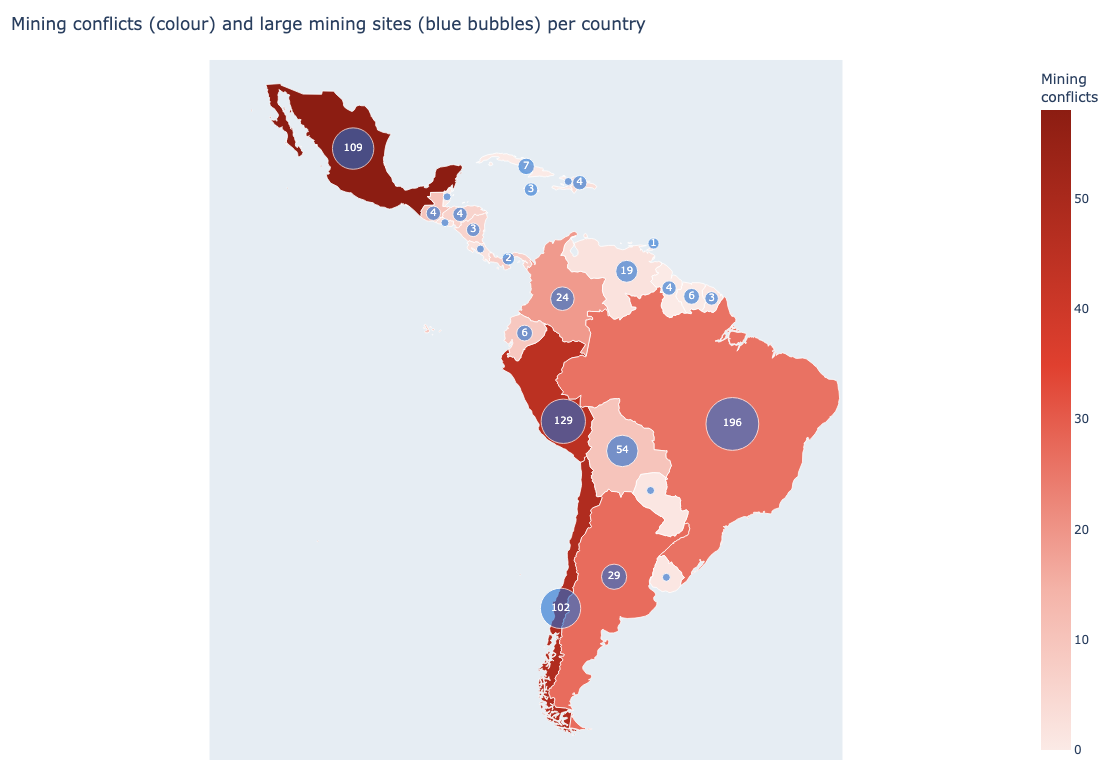

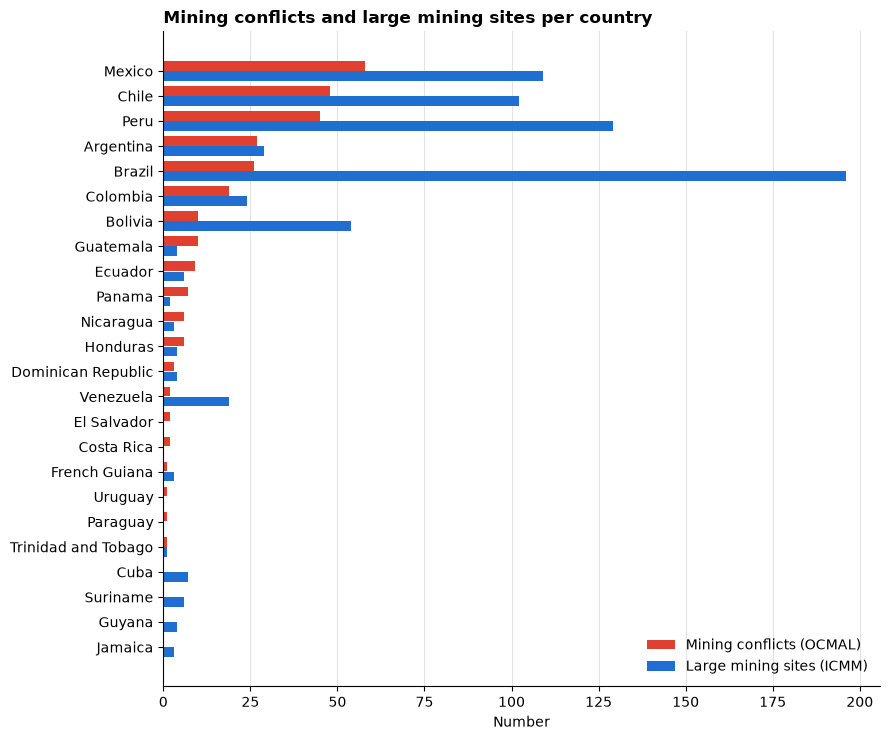

,iso3,country,subregion,n_conflicts,n_sites
0,MEX,Mexico,Mexico & Central America,58,109
1,CHL,Chile,South America,48,102
2,PER,Peru,South America,45,129
3,ARG,Argentina,South America,27,29
4,BRA,Brazil,South America,26,196
5,COL,Colombia,South America,19,24
6,BOL,Bolivia,South America,10,54
7,GTM,Guatemala,Mexico & Central America,10,4
8,ECU,Ecuador,South America,9,6
9,PAN,Panama,Mexico & Central America,7,2


In [19]:
country_table = (pd.DataFrame({"iso3": list(REGION), "country": [v[0] for v in REGION.values()], "subregion": [v[1] for v in REGION.values()]})
                 .merge(conflicts.groupby("iso3").size().rename("n_conflicts"), on="iso3", how="left")
                 .merge(sites.groupby("iso3").size().rename("n_sites"), on="iso3", how="left")
                 .fillna({"n_conflicts": 0, "n_sites": 0}).astype({"n_conflicts": int, "n_sites": int}))
labels = {f["properties"]["iso3"]: (f["properties"]["label_lon"], f["properties"]["label_lat"]) for f in countries_gj["features"]}
country_table["label_lon"] = country_table["iso3"].map(lambda i: labels.get(i, (np.nan, np.nan))[0])
country_table["label_lat"] = country_table["iso3"].map(lambda i: labels.get(i, (np.nan, np.nan))[1])
country_table = country_table.sort_values("n_conflicts", ascending=False).reset_index(drop=True)

try:
    import plotly.graph_objects as go
    t = country_table[country_table["iso3"].isin([f["properties"]["iso3"] for f in countries_gj["features"]])]
    figC = go.Figure([
        go.Choropleth(geojson=countries_gj, featureidkey="properties.iso3", locations=t["iso3"], z=t["n_conflicts"],
                      colorscale=[[0, "#fbeae6"], [0.25, "#f4b3a8"], [0.6, "#e0402f"], [1, "#8c1d12"]],
                      marker_line_color="#ffffff", marker_line_width=0.8, colorbar=dict(title="Mining<br>conflicts", x=0.98),
                      text=t["country"] + ": " + t["n_conflicts"].astype(str) + " conflicts, " + t["n_sites"].astype(str) + " large sites",
                      hovertemplate="%{text}<extra></extra>", name="conflicts"),
        go.Scattergeo(lon=t["label_lon"], lat=t["label_lat"], mode="markers+text", text=t["n_sites"].where(t["n_sites"] > 0, "").astype(str),
                      textfont=dict(size=10, color="#ffffff"), textposition="middle center",
                      marker=dict(size=np.sqrt(t["n_sites"]) * 3.2 + 8, color="rgba(31,111,209,0.85)", line=dict(width=1, color="#ffffff")),
                      hoverinfo="skip", name="large mining sites (bubble area)"),
    ])
    figC.update_geos(visible=False, bgcolor=OCEAN, projection_type="azimuthal equal area", projection_rotation=dict(lon=-78, lat=-10),
                     lonaxis_range=[-120, -34], lataxis_range=[-57, 34])
    figC.update_layout(height=760, margin=dict(l=0, r=0, t=60, b=0),
                       title=dict(text="Mining conflicts (colour) and large mining sites (blue bubbles) per country", x=0.01),
                       legend=dict(x=0.01, y=0.02, bgcolor="rgba(255,255,255,0.85)"))
    show_fig(figC, "C_map_countries.html")
except ImportError:
    print("plotly is not installed. Run: pip install plotly — then run this cell again.")

# the same numbers as a chart (countries with at least one conflict or site)
t = country_table[(country_table["n_conflicts"] > 0) | (country_table["n_sites"] > 0)].sort_values("n_conflicts")
fig, ax = plt.subplots(figsize=(9, 7.5))
y = np.arange(len(t))
ax.barh(y + 0.2, t["n_conflicts"], height=0.38, color=ZONE, label="Mining conflicts (OCMAL)")
ax.barh(y - 0.2, t["n_sites"], height=0.38, color=SITE_COLOURS["critical mineral"], label="Large mining sites (ICMM)")
ax.set_yticks(y)
ax.set_yticklabels(t["country"])
ax.set_xlabel("Number")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e4e3df")
ax.set_axisbelow(True)
ax.set_title("Mining conflicts and large mining sites per country", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "C_countries_bars.png", dpi=200)
plt.show()
country_table.drop(columns=["label_lon", "label_lat"])

In [20]:
# 7) Proposition D — Static maps for the report and the slides
#
# 7A. Drawing tools
#
# What: a few functions used by 7B and 7C.
# - project(): Lambert azimuthal equal-area projection centred on Latin America (lon −78°, lat −10°), in km. Areas keep their true size,
#   and the shape of South America is not stretched as on a plain longitude/latitude map;
# - draw_base(), draw_sites(), draw_zones(): draw layer 1, 2 or 3 on a matplotlib axis;
# - VIEWS: the three views (all of Latin America, the Andes, Mexico & Central America) as longitude/latitude boxes.
#
# Output: nothing is printed.

In [21]:
LON0, LAT0 = np.radians(-78), np.radians(-10)

def project(lon, lat):
    lam, phi = np.radians(np.asarray(lon, float)), np.radians(np.asarray(lat, float))
    k = np.sqrt(2 / (1 + np.sin(LAT0) * np.sin(phi) + np.cos(LAT0) * np.cos(phi) * np.cos(lam - LON0)))
    x = k * np.cos(phi) * np.sin(lam - LON0)
    y = k * (np.cos(LAT0) * np.sin(phi) - np.sin(LAT0) * np.cos(phi) * np.cos(lam - LON0))
    return x * 6371, y * 6371

def rings(geom):
    out = []
    for poly in polygons(geom):
        r = np.array(poly[0])
        x, y = project(r[:, 0], r[:, 1])
        out.append(np.c_[x, y])
    return out

sites["x"], sites["y"] = project(sites["lon"], sites["lat"])
zones["x"], zones["y"] = project(zones["label_lon"], zones["label_lat"])
VIEWS = {"Latin America": (-117.5, -56, -34, 32.8), "Andes": (-82.5, -36.5, -60, -2), "Mexico & Central America": (-118, 6.5, -76.5, 33)}
halo = [pe.withStroke(linewidth=2.2, foreground="#ffffff")]

def frame(ax, view):
    lo0, la0, lo1, la1 = VIEWS[view]
    gx, gy = np.meshgrid(np.linspace(lo0, lo1, 60), np.linspace(la0, la1, 60))
    x, y = project(gx, gy)
    ax.set_xlim(x.min(), x.max()); ax.set_ylim(y.min(), y.max())
    ax.set_aspect("equal"); ax.axis("off")

def draw_base(ax, provinces_lines=False):
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, color=OCEAN, zorder=0))   # the sea (axis("off") hides the axis background)
    for f in countries_gj["features"]:
        p = f["properties"]
        colour = REGION_FILL.get(p["subregion"], OTHER_LAND) if p["in_project"] else OTHER_LAND
        ax.add_collection(PolyCollection(rings(f["geometry"]), facecolors=colour, edgecolors="#ffffff", linewidths=0.8, zorder=1))
    if provinces_lines:
        ax.add_collection(PolyCollection([r for f in provinces_gj["features"] for r in rings(f["geometry"])],
                                         facecolors="none", edgecolors="#b8ae9c", linewidths=0.3, zorder=2))

def draw_sites(ax, size=10):
    for grp in ["other minerals", "gold", "critical mineral"]:
        s = sites[sites["group"] == grp]
        ax.scatter(s["x"], s["y"], s=size, color=SITE_COLOURS[grp], edgecolor="#ffffff", linewidth=0.3, zorder=6, label=f"{grp} ({len(s)})")

def draw_zones(ax, circle=30, label_min=7):
    zone_ids = set(zones["admin1_id"])
    rr = [r for f in provinces_gj["features"] if f["properties"]["admin1_id"] in zone_ids for r in rings(f["geometry"])]
    ax.add_collection(PolyCollection(rr, facecolors=(0.878, 0.251, 0.184, 0.13), edgecolors=(0.878, 0.251, 0.184, 0.55),
                                     linewidths=0.5, zorder=4))
    ax.scatter(zones["x"], zones["y"], s=zones["n_conflicts"] * circle, color=ZONE, alpha=0.45, edgecolor="#a8261a", linewidth=0.7, zorder=5)
    for r in zones[zones["n_conflicts"] >= label_min].itertuples():
        ax.annotate(f"{r.admin1} {r.n_conflicts}", (r.x, r.y), xytext=(6, 0), textcoords="offset points", fontsize=7,
                    fontweight="bold", color="#3a1510", va="center", zorder=7, path_effects=halo)

In [22]:
# 7B. The three layers side by side
#
# What: three maps of the same view in a row: 1 countries, 2 + mining sites, 3 + conflict zones. Change VIEW to "Andes" or "Mexico & Central America" to zoom.
#
# Why: for the written report, where a map cannot build up click by click.
#
# How to read it: large mines follow the Andes (Peru, Chile, Bolivia), northern and central Mexico and south-eastern Brazil.
# The biggest conflict circles sit on the same places: Coquimbo, Atacama and Antofagasta in Chile, Zacatecas and Sonora in Mexico, Cajamarca in Peru, Pará and Minas Gerais in Brazil.
# Exception: Puebla (Mexico) has six conflicts and no large site; its conflicts are about exploration projects and concessions.
#
# Output: the three maps, saved as figures/D_three_layers_<view>.png.

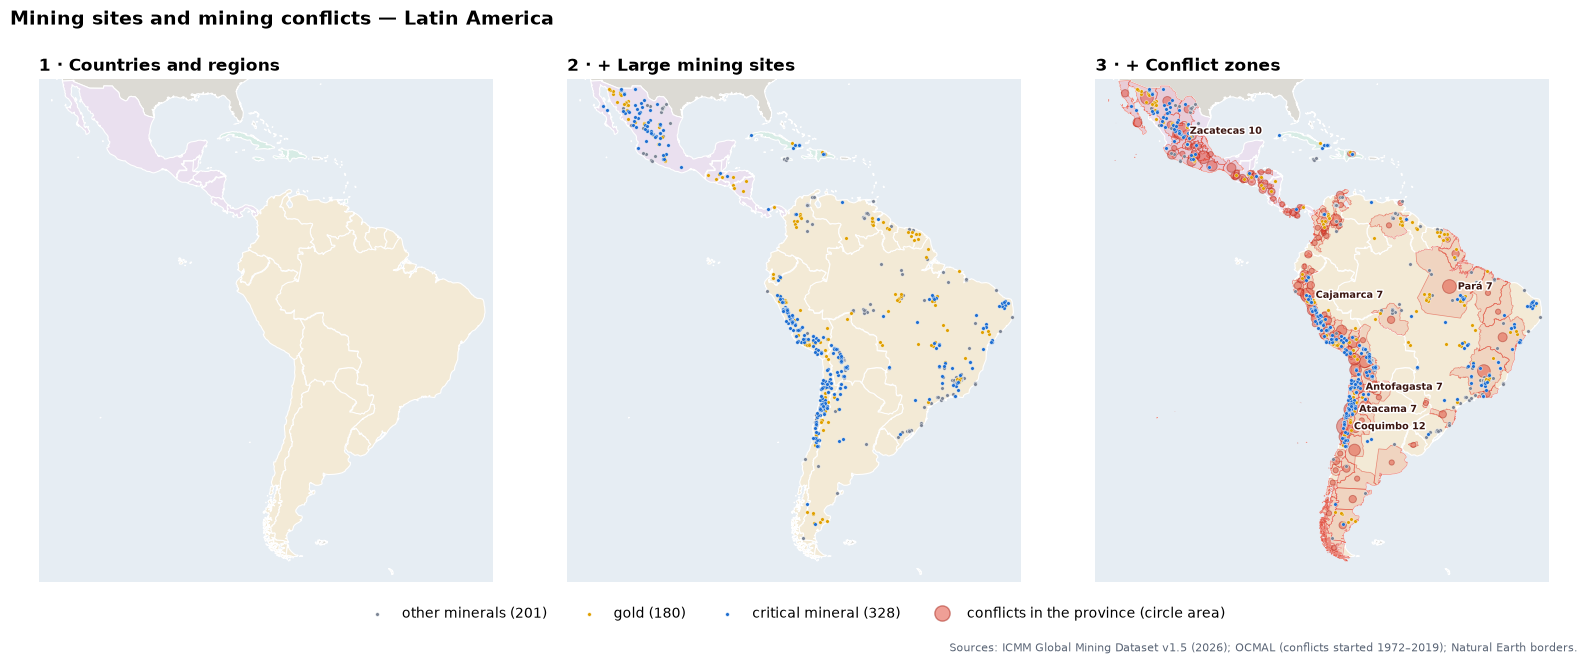

In [23]:
VIEW = "Latin America"

fig, axes = plt.subplots(1, 3, figsize=(16, 6.6), facecolor="#ffffff")
titles = ["1 · Countries and regions", "2 · + Large mining sites", "3 · + Conflict zones"]
for i, ax in enumerate(axes):
    frame(ax, VIEW)
    draw_base(ax, provinces_lines=VIEW != "Latin America")
    if i >= 1:
        draw_sites(ax, size=7 if VIEW == "Latin America" else 18)
    if i == 2:
        draw_zones(ax, circle=14 if VIEW == "Latin America" else 40, label_min=7 if VIEW == "Latin America" else 4)
    ax.set_title(titles[i], loc="left", fontsize=12, fontweight="bold")
handles, labels_ = axes[1].get_legend_handles_labels()
handles.append(plt.Line2D([], [], marker="o", ls="", markersize=11, markerfacecolor=ZONE, alpha=0.5, markeredgecolor="#a8261a"))
labels_.append("conflicts in the province (circle area)")
fig.legend(handles, labels_, loc="lower center", bbox_to_anchor=(0.5, 0.035), ncol=4, frameon=False, fontsize=10)
fig.suptitle(f"Mining sites and mining conflicts — {VIEW}", x=0.01, ha="left", fontsize=14, fontweight="bold")
fig.text(0.99, 0.008, "Sources: ICMM Global Mining Dataset v1.5 (2026); OCMAL (conflicts started 1972–2019); Natural Earth borders.",
         ha="right", fontsize=8, color="#5a6576")
plt.tight_layout(rect=(0, 0.09, 1, 0.95))
plt.savefig(FIG_DIR / f"D_three_layers_{VIEW.replace(' & ', '_').replace(' ', '_')}.png", dpi=200)
plt.show()

In [24]:
# 7C. The layers as separate transparent images, for slides
#
# What: for one view, three PNG files of exactly the same size and frame: the base map (opaque), the mining sites (transparent background)
# and the conflict zones (transparent background, with the sites drawn again on top so they stay sharp).
# In PowerPoint, Google Slides or Keynote, put the three images exactly on top of each other and give the 2nd and 3rd an "Appear" or "Fade" animation:
# the map then builds up in three clicks, like in our deck "Where mining meets conflict".
#
# Output: the three file names, in figures/layers/.

In [25]:
def save_layers(view, height_px=2160):
    out = FIG_DIR / "layers"
    out.mkdir(exist_ok=True)
    lo0, la0, lo1, la1 = VIEWS[view]
    gx, gy = np.meshgrid(np.linspace(lo0, lo1, 60), np.linspace(la0, la1, 60))
    x, y = project(gx, gy)
    width_px = int(height_px * (x.max() - x.min()) / (y.max() - y.min()))
    zoom = view != "Latin America"
    names = []
    for layer in ["1_base", "2_sites", "3_zones"]:
        fig = plt.figure(figsize=(width_px / 200, height_px / 200), dpi=200)
        ax = fig.add_axes([0, 0, 1, 1])
        frame(ax, view)
        if layer == "1_base":
            fig.patch.set_facecolor(OCEAN)
            draw_base(ax, provinces_lines=zoom)
        else:
            fig.patch.set_alpha(0)
            ax.patch.set_alpha(0)
            if layer == "3_zones":
                draw_zones(ax, circle=70 if zoom else 38, label_min=4 if zoom else 7)
            draw_sites(ax, size=40 if zoom else 16)
        name = out / f"{view.replace(' & ', '_').replace(' ', '_')}_{layer}.png"
        fig.savefig(name, dpi=200, transparent=layer != "1_base", facecolor=fig.get_facecolor())
        plt.close(fig)
        names.append(name.name)
    return names

for v in VIEWS:
    print(v, save_layers(v))

Latin America ['Latin_America_1_base.png', 'Latin_America_2_sites.png', 'Latin_America_3_zones.png']
Andes ['Andes_1_base.png', 'Andes_2_sites.png', 'Andes_3_zones.png']
Mexico & Central America ['Mexico_Central_America_1_base.png', 'Mexico_Central_America_2_sites.png', 'Mexico_Central_America_3_zones.png']


In [26]:
# 8) Save the tables behind the maps
#
# What: two CSV files in clean/, to use in the combining step:
# - conflict_zones.csv — one row per conflict (each once) with its province (admin1, admin1_id) and how it was matched;
# - admin1_summary.csv — one row per province with at least one conflict or one large site: conflicts, sites, critical / gold sites, main minerals, years.
# admin1_id = ISO3 + "|" + the Natural Earth province name (e.g. "CHL|Coquimbo"): the same key can be used for the Global Witness data if it gives the province.
#
# Output: the size of each file.

In [27]:
Path("clean").mkdir(exist_ok=True)
conflict_zones_out = conflicts[["conflict_id", "conflict_name", "country", "iso3", "subregion", "admin1", "admin1_id", "matched_on",
                                "start_year", "place_raw"]].sort_values("conflict_id")
admin1_out = provinces[(provinces["n_conflicts"] > 0) | (provinces["n_sites"] > 0)].sort_values(["n_conflicts", "n_sites"], ascending=False)
conflict_zones_out.to_csv("clean/conflict_zones.csv", index=False)
admin1_out.to_csv("clean/admin1_summary.csv", index=False)
print("clean/conflict_zones.csv:", conflict_zones_out.shape, "| clean/admin1_summary.csv:", admin1_out.shape)

clean/conflict_zones.csv: (284, 10) | clean/admin1_summary.csv: (173, 15)


In [28]:
# 9) Which proposition for what, and what the maps can and cannot show
#
# Proposition — Best for — Needs
# A. Plotly, three buttons — presenting live, or sending one HTML file that anyone can open; hover shows each province's conflicts — plotly
# B. Folium / Leaflet — exploring: zoom down to a valley with a real background map — folium, internet for the background map
# C. Country view — combining with the other datasets (IEA, Global Witness), which are per country — plotly, matplotlib
# D. Static maps and layer PNGs — the written report, and slides that build up click by click — matplotlib only
#
# Question — What the maps give — Limit
# Do mines and conflicts happen in the same places? — 78% of the placed conflicts are in provinces that also have large mines;
#   68% of provinces with a large site had a conflict, against 14% without one — An association, not a cause: bigger and better monitored provinces have more of both.
# Where exactly? — Province level for conflicts, exact coordinates for sites — The conflict list has no coordinates; a province can be very large (Pará, Santa Cruz).
# All mining? — Large-scale mines, smelters and refineries (ICMM) — Small-scale and illegal mining (e.g. Amazon gold) is mostly missing.
# Over time? — Conflicts have a start year (1972–2019) — ICMM is a 2026 snapshot with no dates; nothing after 2019 in the conflict list.
#
# Next step for the project: add the Global Witness killings of environmental defenders as a fourth layer, per country or with the same province key (admin1_id).